# Notebook 03 – Transformer Model Training & Evaluation

**Pipeline stages covered:**
1. Load pre-processed splits from Notebook 02
2. Build PyTorch DataLoaders
3. Instantiate Transformer classifier
4. Training loop with live progress
5. Loss & accuracy curves
6. Evaluation: Accuracy · Precision · Recall · F1-Score
7. Confusion matrix (raw + normalized)
8. Per-class metrics bar chart & radar chart
9. ROC curves (one-vs-rest)
10. Save model + all artifacts to `model/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import joblib
from sklearn.metrics import classification_report, confusion_matrix

from utils.model_utils import (
    TransformerClassifier,
    make_dataloaders,
    create_sequences,
    train_model,
    eval_epoch,
    compute_metrics,
    save_model,
)
from utils.visualization import (
    plot_training_history,
    plot_confusion_matrix,
    plot_evaluation_metrics,
    plot_metrics_radar,
    plot_roc_curves,
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'✓ Imports OK  |  Device: {device}')

✓ Imports OK  |  Device: cpu


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR   = '../../data/processed'
MODEL_DIR  = '../../model'

# Transformer hyperparameters
D_MODEL        = 128
N_HEADS        = 4
N_LAYERS       = 2
DIM_FEEDFORWARD= 256
DROPOUT        = 0.1

# Training hyperparameters
N_EPOCHS       = 10
BATCH_SIZE     = 512
LEARNING_RATE  = 1e-3
RANDOM_STATE   = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.makedirs(MODEL_DIR, exist_ok=True)
print('Configuration set.')

Configuration set.


## 1 · Load Pre-processed Splits

In [3]:
# ── Load pre-built sequence data ──────────────────────────────────────────
# Sequences were created in Notebook 02 (before train/test split)
# to ensure temporal continuity within each window.

X_train = np.load(f'{DATA_DIR}/X_train_seq.npy')
X_test  = np.load(f'{DATA_DIR}/X_test_seq.npy')
y_train = np.load(f'{DATA_DIR}/y_train_seq.npy')
y_test  = np.load(f'{DATA_DIR}/y_test_seq.npy')

# Also load per-flow labels for the Random Forest
X_train_rf = np.load(f'{DATA_DIR}/X_train_sc.npy')
X_test_rf  = np.load(f'{DATA_DIR}/X_test_sc.npy')
y_train_rf = np.load(f'{DATA_DIR}/y_train_enc.npy')
y_test_rf  = np.load(f'{DATA_DIR}/y_test_enc.npy')


# Load metadata (class names, etc.)
with open(f'{DATA_DIR}/metadata.json', 'r') as f:
    meta = json.load(f)
class_names = meta['class_names']
selected_features = meta['selected_features']

# Load model artifacts from Notebook 02
scaler = joblib.load(f'{MODEL_DIR}/scaler.pkl')
label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder.pkl')

print(f'Transformer train: X={X_train.shape}, y={y_train.shape}')
print(f'Transformer test:  X={X_test.shape},  y={y_test.shape}')
print(f'Random Forest train: X={X_train_rf.shape}, y={y_train_rf.shape}')
print(f'Random Forest test:  X={X_test_rf.shape},  y={y_test_rf.shape}')

Transformer train: X=(1439418, 10, 20), y=(1439418, 12)
Transformer test:  X=(359855, 10, 20),  y=(359855, 12)
Random Forest train: X=(1439425, 20), y=(1439425, 12)
Random Forest test:  X=(359857, 20),  y=(359857, 12)


## 1.5 · Sort Data by Original Index (Chronological Order)

> `train_test_split` shuffles the data, but the sliding window in `create_sequences`
> requires chronological ordering to produce meaningful temporal sequences.
> We use the original DataFrame indices preserved in `y_train_raw` / `y_test_raw`
> to restore the original order.

In [4]:
# ── Sequences already created in Notebook 02 ──────────────────────────────
# No need to call create_sequences here; sequences were built before
# train/test split to ensure temporal continuity.
# The X_train/X_test variables already contain 3D sequence data:
#   shape (n_sequences, seq_len, n_features)
print('Sequences loaded from Notebook 02 (pre-split).')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')

Sequences loaded from Notebook 02 (pre-split).
  X_train: (1439418, 10, 20)
  X_test:  (359855, 10, 20)


## 2 · Build DataLoaders

In [5]:
# ── Build DataLoaders from pre-built sequences ─────────────────────────────
# X_train/X_test are already 3D: (n_sequences, seq_len, n_features)
n_features = X_train.shape[2]   # features per flow
n_classes  = y_train.shape[1]   # number of classes (one-hot encoded)

train_loader, test_loader = make_dataloaders(
    X_train, y_train, X_test, y_test, batch_size=BATCH_SIZE
)

print(f'n_features: {n_features}  |  n_classes: {n_classes}')
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')
print(f'Sequence shape: ({X_train.shape[1]}, {n_features})')

n_features: 20  |  n_classes: 12
Train batches: 2812  |  Test batches: 703
Sequence shape: (10, 20)


## 3 · Instantiate Transformer Classifier

In [6]:
model = TransformerClassifier(
    n_features=n_features,
    n_classes=n_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

TransformerClassifier(
  (input_proj): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential

## 4 · Training

In [7]:
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    verbose=True,
)

Epoch   1/10 │ Train Loss: 0.4889  Acc: 0.7769 │ Val Loss: 0.4400  Acc: 0.7960 │ LR: 9.76e-04
Epoch   2/10 │ Train Loss: 0.4457  Acc: 0.7932 │ Val Loss: 0.4373  Acc: 0.7970 │ LR: 9.05e-04
Epoch   3/10 │ Train Loss: 0.4370  Acc: 0.7970 │ Val Loss: 0.4268  Acc: 0.8020 │ LR: 7.94e-04
Epoch   4/10 │ Train Loss: 0.4308  Acc: 0.7999 │ Val Loss: 0.4266  Acc: 0.8008 │ LR: 6.55e-04
Epoch   5/10 │ Train Loss: 0.4260  Acc: 0.8023 │ Val Loss: 0.4207  Acc: 0.8070 │ LR: 5.00e-04
Epoch   6/10 │ Train Loss: 0.4222  Acc: 0.8045 │ Val Loss: 0.4184  Acc: 0.8079 │ LR: 3.45e-04
Epoch   7/10 │ Train Loss: 0.4185  Acc: 0.8061 │ Val Loss: 0.4127  Acc: 0.8097 │ LR: 2.06e-04
Epoch   8/10 │ Train Loss: 0.4154  Acc: 0.8077 │ Val Loss: 0.4109  Acc: 0.8111 │ LR: 9.55e-05
Epoch   9/10 │ Train Loss: 0.4128  Acc: 0.8088 │ Val Loss: 0.4076  Acc: 0.8124 │ LR: 2.45e-05
Epoch  10/10 │ Train Loss: 0.4112  Acc: 0.8099 │ Val Loss: 0.4069  Acc: 0.8128 │ LR: 0.00e+00


## 5 · Training History

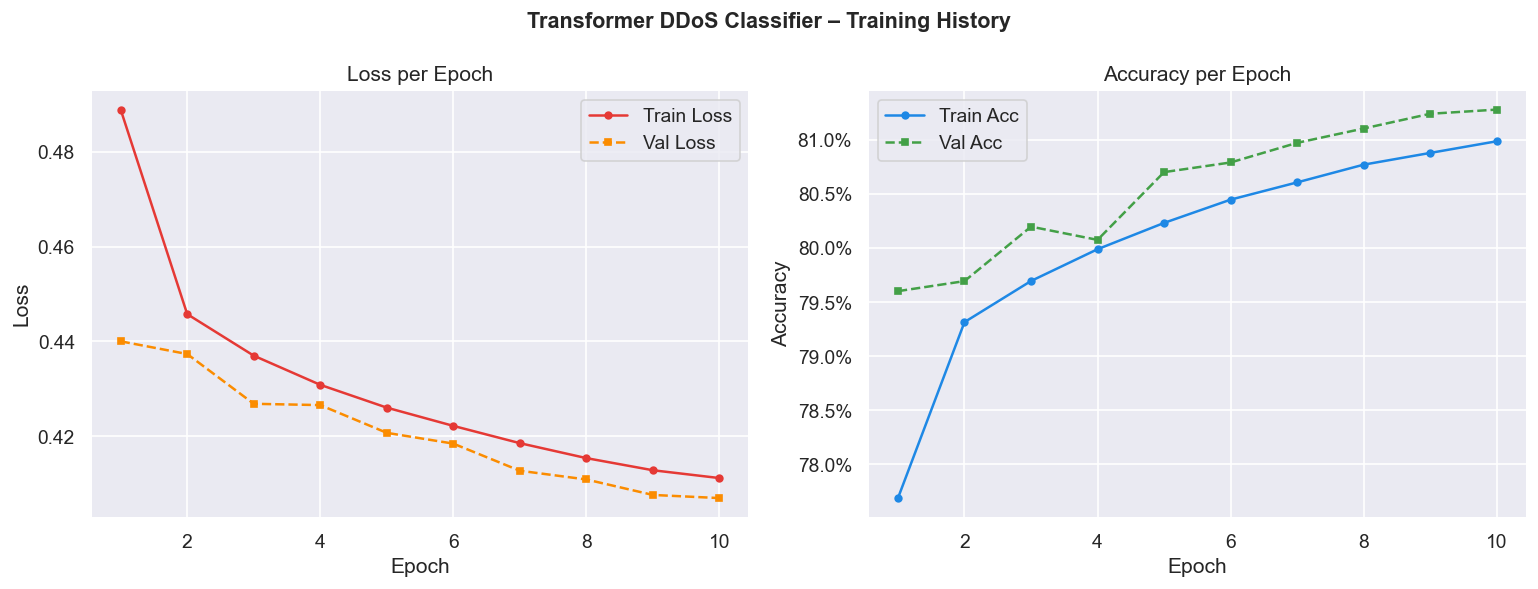

Best train acc : 0.8099
Best val acc   : 0.8128
Best val loss  : 0.4069


In [8]:
fig = plot_training_history(history, title='Transformer DDoS Classifier – Training History')
fig.savefig(f'{DATA_DIR}/fig_12_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

best_train_acc = max(history['train_acc'])
best_val_acc   = max(history['val_acc'])
best_val_loss  = min(history['val_loss'])
print(f'Best train acc : {best_train_acc:.4f}')
print(f'Best val acc   : {best_val_acc:.4f}')
print(f'Best val loss  : {best_val_loss:.4f}')

## 6 · Final Evaluation on Test Set

In [9]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_pred_idx, y_true_idx, y_probs = eval_epoch(
    model, test_loader, criterion, device
)

print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 0.4069
Test Accuracy : 0.8128  (81.28%)


In [10]:
# Full classification report
metrics = compute_metrics(y_true_idx, y_pred_idx, class_names)

print('=== Classification Report ===')
print(classification_report(
    y_true_idx, y_pred_idx,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

=== Classification Report ===
               precision    recall  f1-score   support

       Benign     0.9999    1.0000    0.9999     29934
   DrDoS_LDAP     0.8630    0.9979    0.9256     29999
  DrDoS_MSSQL     0.8961    0.7690    0.8277     29998
    DrDoS_NTP     0.9990    0.9999    0.9995     29998
DrDoS_NetBIOS     0.5684    0.4751    0.5176     29983
   DrDoS_SNMP     0.5159    0.6188    0.5627     29998
   DrDoS_SSDP     0.8028    0.7367    0.7684     29998
    DrDoS_UDP     0.6739    0.7999    0.7315     29970
      Portmap     0.5994    0.5693    0.5839     29994
          Syn     0.9929    0.9959    0.9944     30000
         TFTP     0.9871    0.9916    0.9894     29993
      UDP-lag     0.9017    0.7997    0.8476     29990

     accuracy                         0.8128    359855
    macro avg     0.8167    0.8128    0.8123    359855
 weighted avg     0.8166    0.8128    0.8123    359855



## 7 · Confusion Matrix

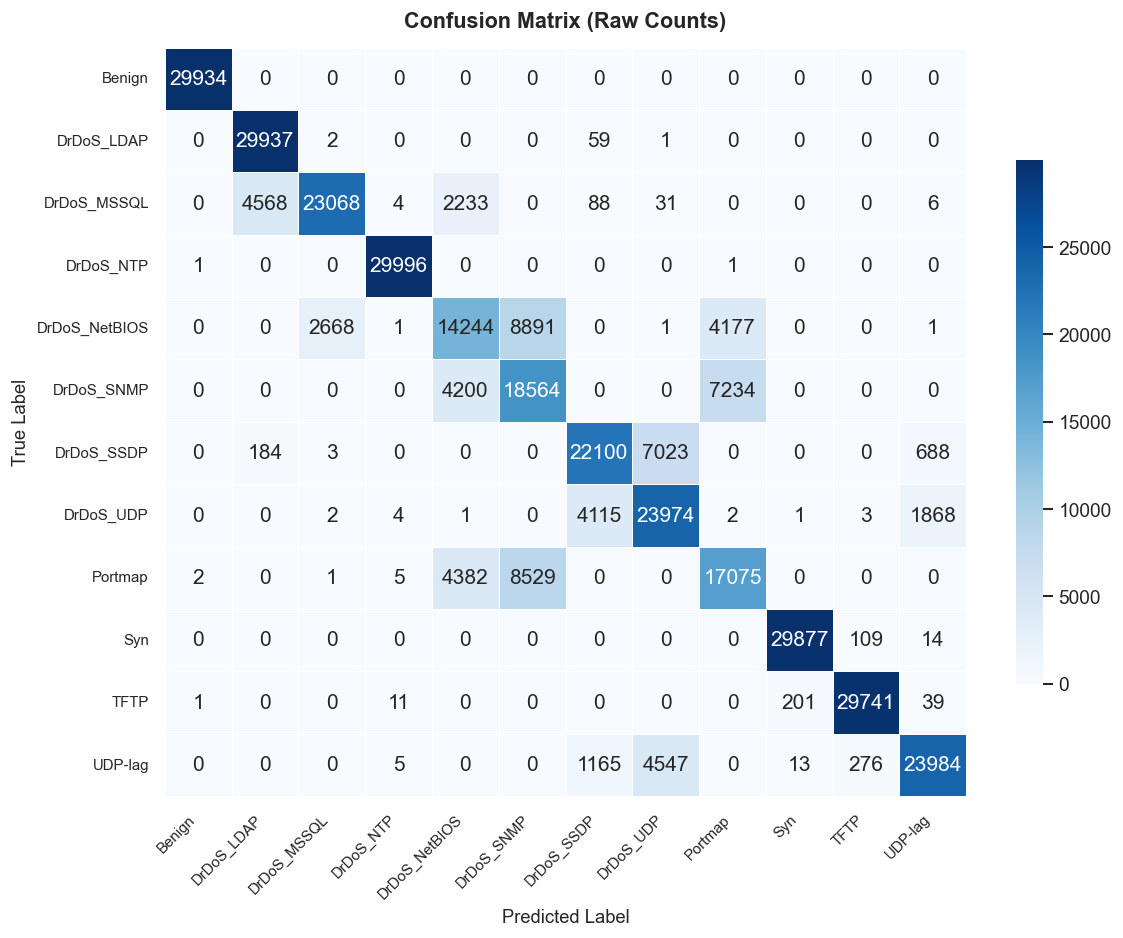

In [11]:
cm = metrics['confusion_matrix']

# Raw counts
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Raw Counts)',
                             normalize=False)
fig.savefig(f'{DATA_DIR}/fig_13_cm_raw.png', dpi=120, bbox_inches='tight')
plt.show()

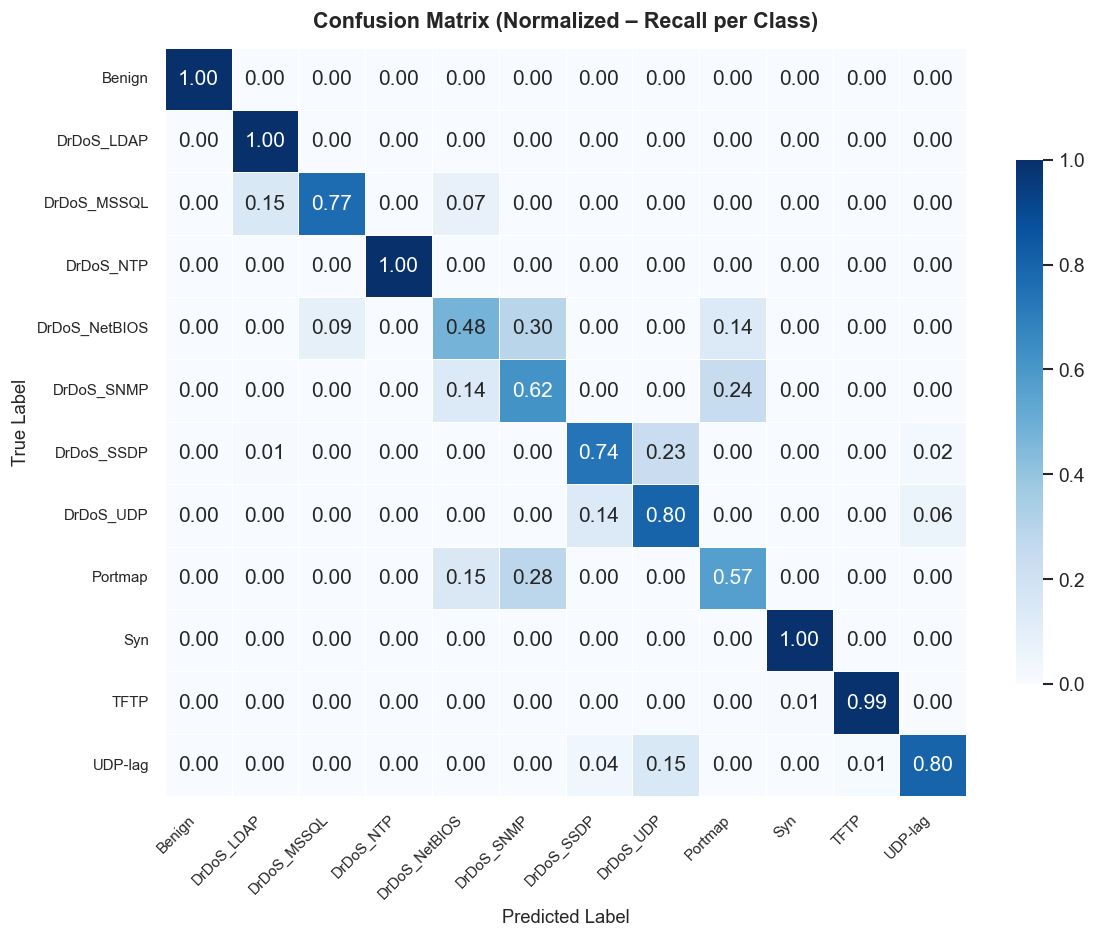

In [12]:
# Normalized (recall per class)
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Normalized – Recall per Class)',
                             normalize=True)
fig.savefig(f'{DATA_DIR}/fig_14_cm_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Evaluation Metrics – Bar Chart & Radar Chart

In [13]:
# Summary table
skip_keys = {'accuracy', 'macro avg', 'weighted avg', 'confusion_matrix'}
metrics_table = {
    cls: {k: round(v, 4) for k, v in vals.items() if k != 'support'}
    for cls, vals in metrics.items()
    if cls not in skip_keys
}
metrics_table['accuracy'] = round(metrics['accuracy'], 4)
metrics_table['macro avg']    = {k: round(v, 4) for k, v in metrics['macro avg'].items()    if k != 'support'}
metrics_table['weighted avg'] = {k: round(v, 4) for k, v in metrics['weighted avg'].items() if k != 'support'}

summary_df = pd.DataFrame(metrics_table).T
print('=== Metrics Summary ===')
display(summary_df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))

=== Metrics Summary ===


,precision,recall,f1-score
Benign,0.999900,1.000000,0.999900
DrDoS_LDAP,0.863000,0.997900,0.925600
DrDoS_MSSQL,0.896100,0.769000,0.827700
DrDoS_NTP,0.999000,0.999900,0.999500
DrDoS_NetBIOS,0.568400,0.475100,0.517600
DrDoS_SNMP,0.515900,0.618800,0.562700
DrDoS_SSDP,0.802800,0.736700,0.768400
DrDoS_UDP,0.673900,0.799900,0.731500
Portmap,0.599400,0.569300,0.583900
Syn,0.992900,0.995900,0.994400


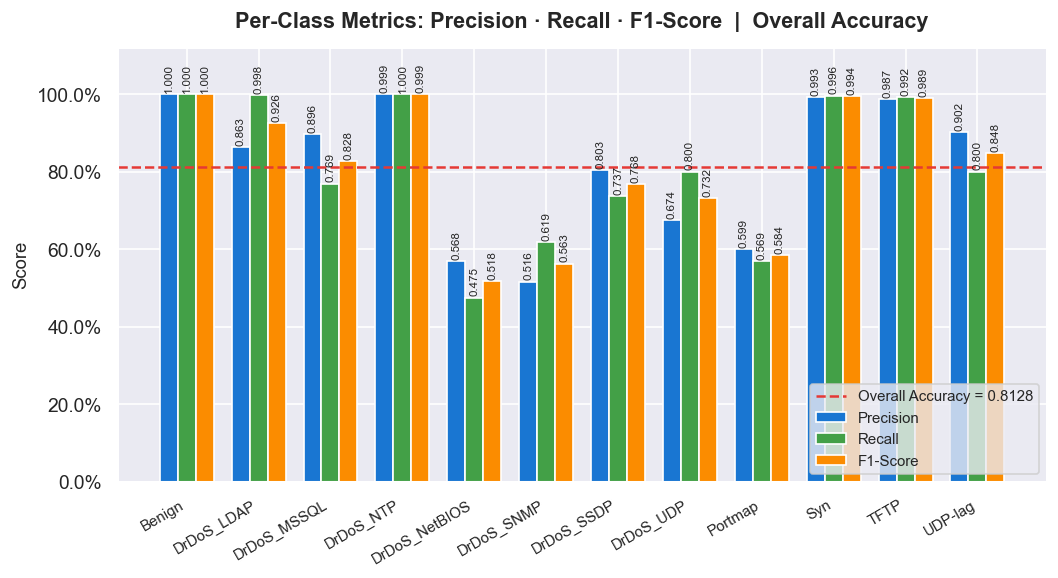

In [14]:
# Grouped bar chart: Precision, Recall, F1 per class
fig = plot_evaluation_metrics(
    metrics,
    title='Per-Class Metrics: Precision · Recall · F1-Score  |  Overall Accuracy'
)
fig.savefig(f'{DATA_DIR}/fig_15_metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()

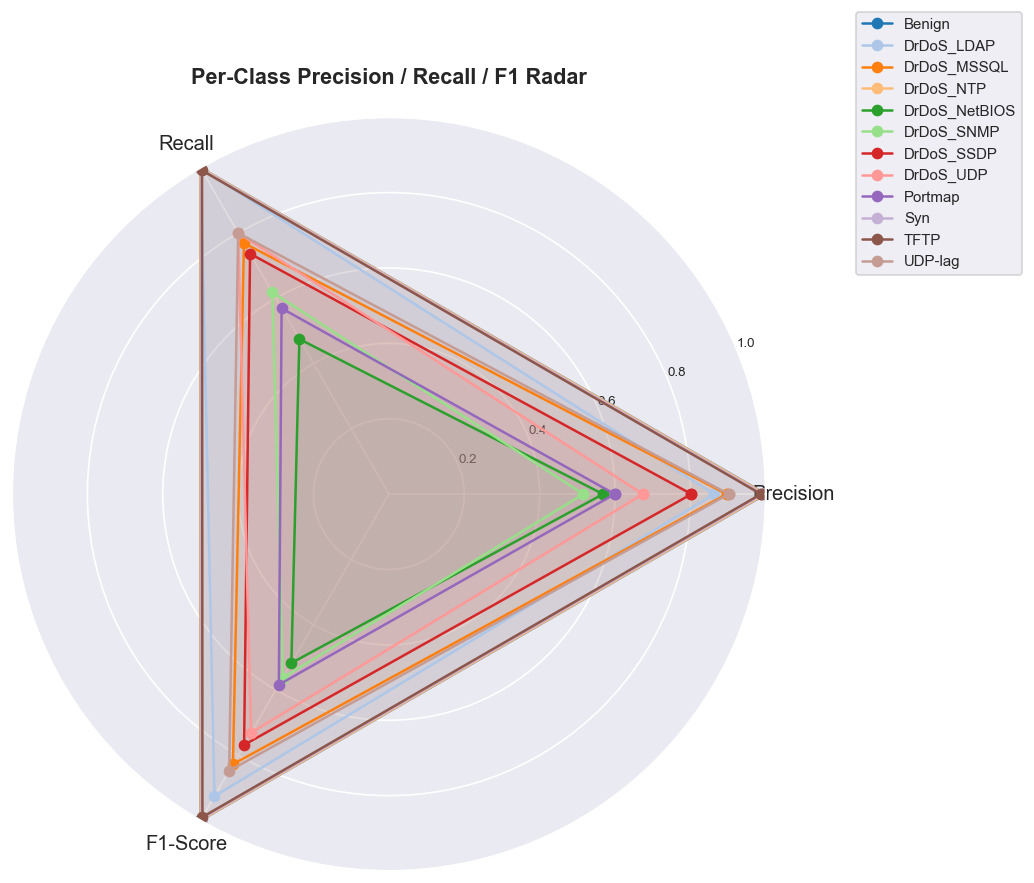

In [15]:
# Radar chart
fig = plot_metrics_radar(metrics, title='Per-Class Precision / Recall / F1 Radar')
fig.savefig(f'{DATA_DIR}/fig_16_metrics_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · ROC Curves (One-vs-Rest)

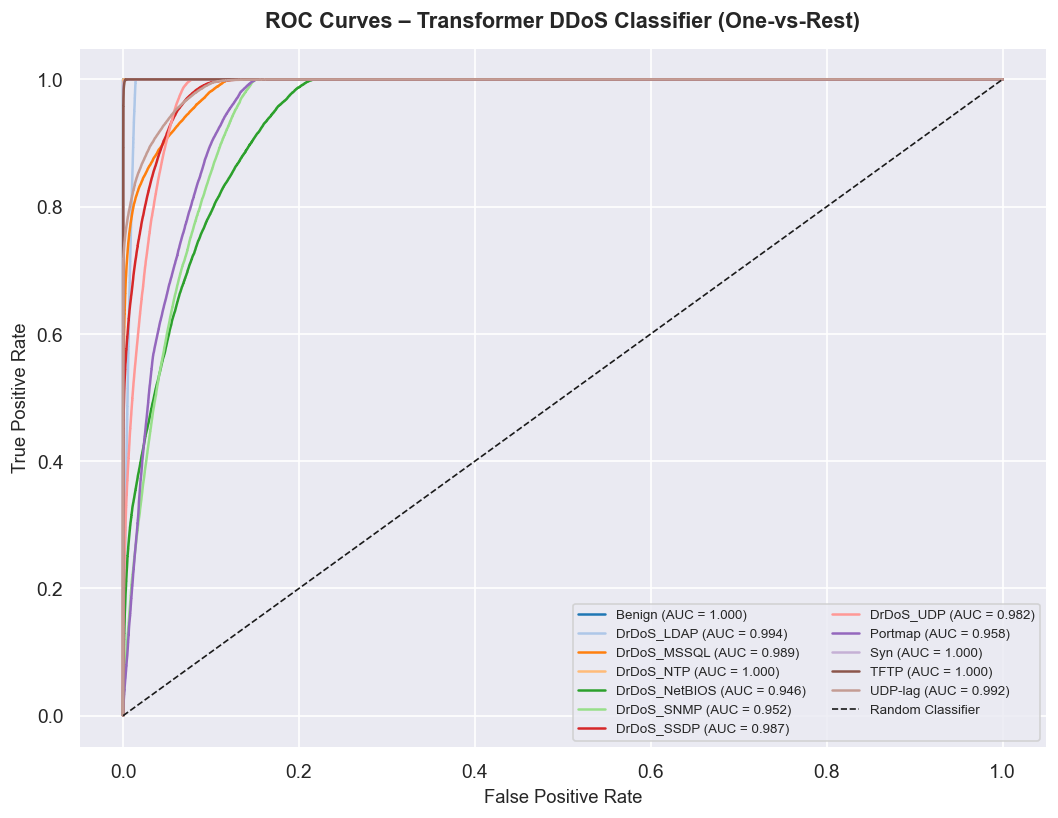

In [16]:
fig = plot_roc_curves(
    y_true_onehot=y_test,
    y_prob=y_probs,
    class_names=class_names,
    title='ROC Curves – Transformer DDoS Classifier (One-vs-Rest)',
)
fig.savefig(f'{DATA_DIR}/fig_17_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10 · Per-Epoch Accuracy & Loss Summary Table

In [17]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = 'Epoch'

# Highlight best epochs
display(
    history_df.style
    .highlight_max(subset=['train_acc', 'val_acc'], color='#C8E6C9')
    .highlight_min(subset=['train_loss', 'val_loss'], color='#BBDEFB')
    .format('{:.4f}')
)

,train_loss,val_loss,train_acc,val_acc
Epoch,,,,
1,0.4889,0.4400,0.7769,0.7960
2,0.4457,0.4373,0.7932,0.7970
3,0.4370,0.4268,0.7970,0.8020
4,0.4308,0.4266,0.7999,0.8008
5,0.4260,0.4207,0.8023,0.8070
6,0.4222,0.4184,0.8045,0.8079
7,0.4185,0.4127,0.8061,0.8097
8,0.4154,0.4109,0.8077,0.8111
9,0.4128,0.4076,0.8088,0.8124


## 11 · Save Model & Artifacts

In [18]:
save_model(
    model=model,
    scaler=scaler,
    label_encoder=label_encoder,
    selected_features=selected_features,
    model_dir=MODEL_DIR,
)

print('\n=== Saved Artifacts ===')
for root, dirs, files in os.walk(MODEL_DIR):
    for fname in files:
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        print(f'  {fname:<35}  {size/1024:.1f} KB')

[model_utils] Model and artifacts saved to '../../model/'

=== Saved Artifacts ===
  .keep                                0.0 KB
  label_encoder.pkl                    1.0 KB
  random_forest_ddos.pkl               3527678.7 KB
  scaler.pkl                           4.8 KB
  selected_features.json               0.4 KB
  transformer_ddos.pt                  1385.1 KB
  label_encoder.pkl                    0.8 KB
  random_forest_ddos.pkl               311587.3 KB
  scaler.pkl                           5.3 KB
  selected_features.json               0.5 KB
  transformer_ddos.pt                  1129.7 KB
  label_encoder.pkl                    0.5 KB
  random_forest_ddos.pkl               10999.4 KB
  scaler.pkl                           5.4 KB
  selected_features.json               0.5 KB
  transformer_ddos.pt                  1123.7 KB


In [19]:
# Final summary
print('=' * 55)
print('  FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Architecture  : Transformer ({N_LAYERS} layers, {N_HEADS} heads, d={D_MODEL})')
print(f'  Input features: {n_features}')
print(f'  Output classes: {n_classes}')
print(f'  Epochs trained: {N_EPOCHS}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {metrics["macro avg"]["f1-score"]*100:.2f}%')
print(f'  Weighted F1   : {metrics["weighted avg"]["f1-score"]*100:.2f}%')
print('=' * 55)

  FINAL MODEL SUMMARY
  Architecture  : Transformer (2 layers, 4 heads, d=128)
  Input features: 20
  Output classes: 12
  Epochs trained: 10
  Test Accuracy : 81.28%
  Macro F1      : 81.23%
  Weighted F1   : 81.23%


---
# Part II – Random Forest Multiclassifier

**Pipeline stages covered:**
1. Prepare integer labels from the one-hot-encoded arrays
2. Train a scikit-learn `RandomForestClassifier` on the same splits
3. Evaluation: Accuracy · Precision · Recall · F1-Score
4. Confusion matrix (raw + normalised)
5. Per-class metrics bar chart & radar chart
6. ROC curves (one-vs-rest)
7. Save RF model to `model/`

## RF-1 · Prepare Integer Labels

In [20]:
# Convert one-hot encoded labels back to integer class indices
# y_train_int = np.argmax(y_train, axis=1)
# y_test_int  = np.argmax(y_test,  axis=1)

# Flatten 3D sequences into 2D arrays for Random Forest (batch, seq_len * features)
# X_train_rf = X_train.reshape(X_train.shape[0], -1)
# X_test_rf  = X_test.reshape(X_test.shape[0], -1)

# print(f'y_train_int shape : {y_train_int.shape}  unique classes: {np.unique(y_train_int).tolist()}')
# print(f'y_test_int  shape : {y_test_int.shape}')\n
# print(f'X_train_rf  shape : {X_train_rf.shape}')
# print(f'X_test_rf   shape : {X_test_rf.shape}')


## RF-2 · Train Random Forest

In [21]:
# import time
# from sklearn.ensemble import RandomForestClassifier

# RF_N_ESTIMATORS     = 100
# RF_MAX_DEPTH        = None   # grow full trees
# RF_MIN_SAMPLES_LEAF = 2
# RF_RANDOM_STATE     = RANDOM_STATE

# rf_model = RandomForestClassifier(
#     n_estimators=RF_N_ESTIMATORS,
#     max_depth=RF_MAX_DEPTH,
#     min_samples_leaf=RF_MIN_SAMPLES_LEAF,
#     class_weight='balanced',
#     random_state=RF_RANDOM_STATE,
#     n_jobs=-1,           # use all CPU cores
#     verbose=1,
# )

# t0 = time.time()
# rf_model.fit(X_train_rf, y_train_int)
# elapsed = time.time() - t0
# print(f'\nTraining complete in {elapsed:.1f}s')

## RF-3 · Evaluate on Test Set

In [22]:
# from sklearn.metrics import accuracy_score

# rf_y_pred = rf_model.predict(X_test_rf)
# rf_y_prob = rf_model.predict_proba(X_test_rf)   # shape (n_samples, n_classes)

# rf_test_acc = accuracy_score(y_test_int, rf_y_pred)
# print(f'Test Accuracy : {rf_test_acc:.4f}  ({rf_test_acc*100:.2f}%)')

In [23]:
# Full classification report
# rf_metrics = compute_metrics(y_test_int, rf_y_pred, class_names)

# print('=== Classification Report ===')
# print(classification_report(
#     y_test_int, rf_y_pred,
#     target_names=class_names,
#     digits=4,
#     zero_division=0,
# ))

## RF-4 · Confusion Matrix

In [24]:
# rf_cm = confusion_matrix(y_test_int, rf_y_pred)
# fig = plot_confusion_matrix(rf_cm, class_names,
#                              title='Confusion Matrix – Random Forest DDoS Classifier',
#                              normalize=True)
# fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_norm.png', dpi=120, bbox_inches='tight')
# plt.show()

In [25]:
# rf_cm = confusion_matrix(y_test_int, rf_y_pred)
# fig = plot_confusion_matrix(rf_cm, class_names,
#                              title='Confusion Matrix (raw counts) – Random Forest DDoS Classifier',
#                              normalize=False)
# fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_raw.png', dpi=120, bbox_inches='tight')
# plt.show()

## RF-5 · Per-Class Metrics

In [26]:
# fig = plot_evaluation_metrics(
#     metrics=rf_metrics,
#     title='Per-Class Metrics – Random Forest DDoS Classifier',
# )
# fig.savefig(f'{DATA_DIR}/fig_rf_per_class_metrics.png', dpi=120, bbox_inches='tight')
# plt.show()

In [27]:
# fig = plot_metrics_radar(
#     metrics=rf_metrics,
#     title='Radar Chart – Random Forest DDoS Classifier',
# )
# fig.savefig(f'{DATA_DIR}/fig_rf_radar.png', dpi=120, bbox_inches='tight')
# plt.show()

## RF-6 · ROC Curves (One-vs-Rest)

In [28]:
# fig = plot_roc_curves(
#     y_true_onehot=y_test,
#     y_prob=rf_y_prob,
#     class_names=class_names,
#     title='ROC Curves – Random Forest DDoS Classifier (One-vs-Rest)',
# )
# fig.savefig(f'{DATA_DIR}/fig_rf_roc_curves.png', dpi=120, bbox_inches='tight')
# plt.show()

## RF-7 · Save Random Forest Model

In [29]:
# import joblib, os

# rf_model_path = os.path.join(MODEL_DIR, 'random_forest_ddos.pkl')
# joblib.dump(rf_model, rf_model_path)
# print(f'Random Forest model saved to: {rf_model_path}')
# size_kb = os.path.getsize(rf_model_path) / 1024
# print(f'File size: {size_kb:.1f} KB')

# print('\n=== Saved Artifacts ===')
# for root, dirs, files in os.walk(MODEL_DIR):
#     for fname in sorted(files):
#         fpath = os.path.join(root, fname)
#         size  = os.path.getsize(fpath)
#         print(f'  {fname:<40}  {size/1024:.1f} KB')

In [30]:
# Final RF summary
# print('=' * 55)
# print('  FINAL RANDOM FOREST MODEL SUMMARY')
# print('=' * 55)
# print(f'  Algorithm     : RandomForestClassifier')
# print(f'  N estimators  : {RF_N_ESTIMATORS}')
# print(f'  Max depth     : {RF_MAX_DEPTH}')
# print(f'  Input features: {n_features}')
# print(f'  Output classes: {n_classes}')
# print(f'  Test Accuracy : {rf_test_acc*100:.2f}%')
# print(f'  Macro F1      : {rf_metrics["macro avg"]["f1-score"]*100:.2f}%')
# print(f'  Weighted F1   : {rf_metrics["weighted avg"]["f1-score"]*100:.2f}%')
# print('=' * 55)